In [1]:
!pip install mediapipe opencv-python matplotlip

ERROR: Could not find a version that satisfies the requirement matplotlip (from versions: none)
ERROR: No matching distribution found for matplotlip


In [2]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.


In [3]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))
print(mp.solutions)

MediaPipe version: 0.10.13
Has solutions: True
<module 'mediapipe.python.solutions' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/__init__.py'>


In [7]:
import cv2
import pandas as pd

In [8]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_draw = mp.solutions.drawing_utils

In [55]:
IMAGE_PATH = "/content/drive/MyDrive/Colab Notebooks/YOGAimages (2).jpg"
image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError("Image not found. Check the path.")

h, w, _ = image.shape
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [56]:
results = pose.process(rgb_image)

In [57]:
BODY_POINTS = {
    "HEAD": mp_pose.PoseLandmark.NOSE,
    "LEFT_SHOULDER": mp_pose.PoseLandmark.LEFT_SHOULDER,
    "RIGHT_SHOULDER": mp_pose.PoseLandmark.RIGHT_SHOULDER,
    "LEFT_ELBOW": mp_pose.PoseLandmark.LEFT_ELBOW,
    "RIGHT_ELBOW": mp_pose.PoseLandmark.RIGHT_ELBOW,
    "LEFT_HIP": mp_pose.PoseLandmark.LEFT_HIP,
    "RIGHT_HIP": mp_pose.PoseLandmark.RIGHT_HIP,
    "LEFT_KNEE": mp_pose.PoseLandmark.LEFT_KNEE,
    "RIGHT_KNEE": mp_pose.PoseLandmark.RIGHT_KNEE,
}

if results.pose_landmarks:
    landmarks = results.pose_landmarks.landmark

    print("\n--- DETECTED POSE COORDINATES (x, y) ---")
    for name, idx in BODY_POINTS.items():
        lm = landmarks[idx]
        x = int(lm.x * w)
        y = int(lm.y * h)

        print(f"{name}: ({x}, {y})")


--- DETECTED POSE COORDINATES (x, y) ---
HEAD: (124, 128)
LEFT_SHOULDER: (152, 113)
RIGHT_SHOULDER: (149, 109)
LEFT_ELBOW: (155, 148)
RIGHT_ELBOW: (151, 138)
LEFT_HIP: (166, 57)
RIGHT_HIP: (163, 56)
LEFT_KNEE: (122, 26)
RIGHT_KNEE: (125, 29)


array([[[177, 186, 195],
        [184, 193, 202],
        [179, 188, 197],
        ...,
        [175, 185, 202],
        [173, 186, 202],
        [173, 186, 202]],

       [[177, 186, 195],
        [186, 195, 204],
        [179, 188, 197],
        ...,
        [179, 189, 206],
        [177, 190, 206],
        [177, 190, 206]],

       [[178, 187, 196],
        [188, 197, 206],
        [179, 188, 197],
        ...,
        [181, 191, 208],
        [179, 192, 208],
        [179, 192, 208]],

       ...,

       [[180, 187, 196],
        [180, 187, 196],
        [180, 187, 196],
        ...,
        [176, 185, 195],
        [176, 185, 195],
        [176, 185, 195]],

       [[179, 186, 195],
        [179, 186, 195],
        [178, 185, 194],
        ...,
        [175, 184, 194],
        [175, 184, 194],
        [175, 184, 194]],

       [[178, 185, 194],
        [178, 185, 194],
        [177, 184, 193],
        ...,
        [174, 183, 193],
        [174, 183, 193],
        [174, 183, 193]]], dtype=uint8)
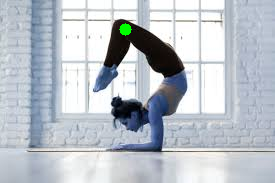

In [58]:
cv2.circle(image, (x, y), 6, (0, 255, 0), -1)

In [59]:
cv2.putText(
            image,
            f"{name} ({x},{y})",
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 0, 0),
            1
        )

print("--------------------------------------")


--------------------------------------


In [60]:
if results.pose_landmarks:
    landmarks = results.pose_landmarks.landmark

    # draw skeleton
    mp_draw.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS
    )

else:
    print("❌ No pose detected")


In [61]:
import matplotlib.pyplot as plt


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

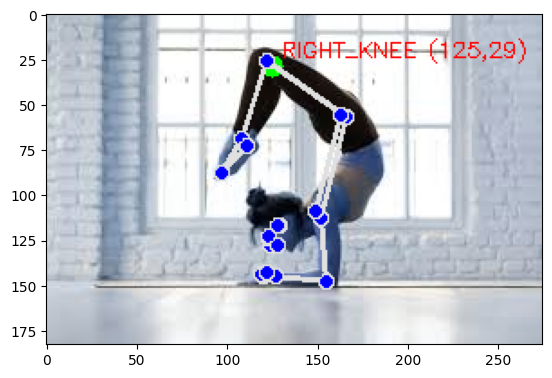

In [62]:
plt.imshow( image)
plt